/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/envs/registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/

findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


...

findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


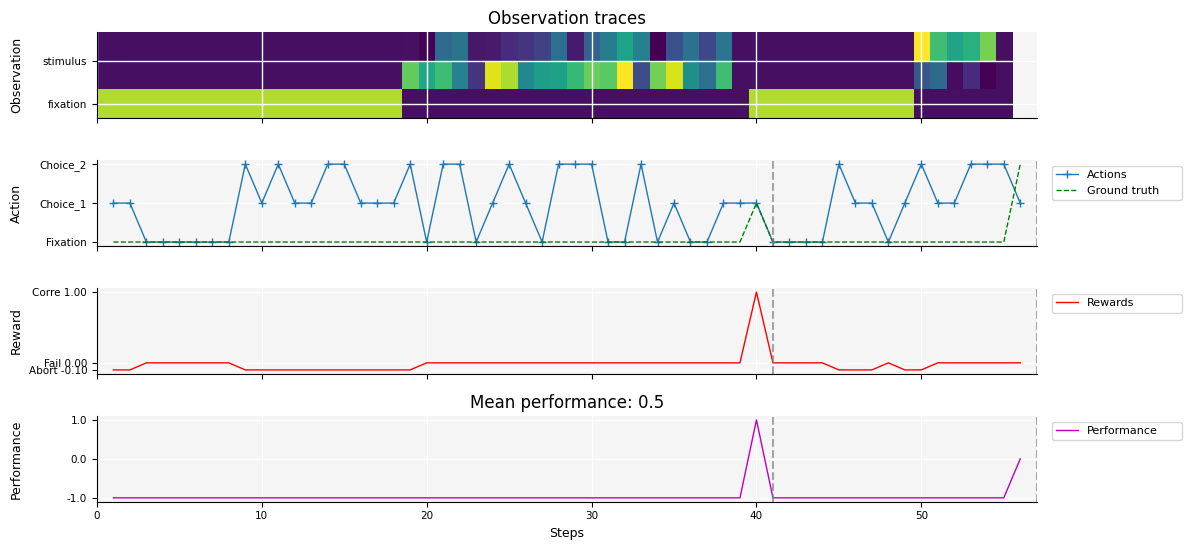

In [1]:
""" Defining a perceptual decision making task (2 choices) """
# import the task from the neurogym library
import neurogym as ngym

# Environment
task = 'PerceptualDecisionMaking-v0'
timing = {
    'fixation': ('choice', (50, 100, 200, 400)),
    'stimulus': ('choice', (100, 200, 400, 800)),
}
kwargs = {'dt': 20, 'timing': timing}
seq_len = 100

# Make supervised dataset
dataset = ngym.Dataset(task, env_kwargs=kwargs, batch_size=16,
                       seq_len=seq_len)

# A sample environment from dataset
env = dataset.env
# Visualize the environment with 2 sample trials
_ = ngym.utils.plot_env(env, num_trials=2)

# Network input and output size
input_size = env.observation_space.shape[0] # 3: fixation - 0, stimulus 1 and 2
output_size = env.action_space.n # 3

In [2]:
import torch
import torch.nn as nn 
from torch.nn import init 
from torch.nn import functional as F 
import math
import numpy as np

""" Construct RNN with Dale's Law """
# hidden layer weight matrix
class EIRecLinear(nn.Module):
    __constants__ = ['bias', 'hidden_size', 'e_prop'] # things don't change with training
    def __init__(self, hidden_size, e_prop, bias=False): # bias (h2h) is True biologically, but for W recovery, False might be better
        super().__init__()
        self.hidden_size = hidden_size
        self.e_prop = e_prop
        self.e_size = int(e_prop * hidden_size)
        self.i_size = hidden_size - self.e_size
        self.weight = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        mask = np.tile([1]*self.e_size+[-1]*self.i_size, (hidden_size, 1)) # W_ij = neuron j (column) -> neuron i
        np.fill_diagonal(mask, 0)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        if bias:
            self.bias = nn.Parameter(torch.Tensor(hidden_size))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        self.weight.data[:, :self.e_size] /= (self.e_size/self.i_size) # there are more E neurons than I neurons, so rescaling the weight by E/I
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight) # fan_in = hidden layer size
            bound = 1 / math.sqrt(fan_in)
            init.uniform_(self.bias, -bound, bound)

    def effective_weight(self):
        return torch.abs(self.weight) * self.mask
    
    def forward(self, input):
        return F.linear(input, self.effective_weight(), self.bias) # input = hidden state (t-1) = r_t-1

# import recurrent
class EIRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dt=None, e_prop=0.8, sigma_rec=0, **kwargs):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.e_size = int(hidden_size * e_prop)
        self.i_size = hidden_size - self.e_size
        self.num_layers = 1
        self.tau = 100
        if dt is None:
            alpha = 1
        else:
            alpha = dt / self.tau
        self.alpha = alpha
        self.oneminusalpha = 1 - alpha
        self._sigma_rec = np.sqrt(2*alpha) * sigma_rec # noise in RNN, sigma * dt/tau --SD-> sigma * sqrt(dt/tau)
        self.input2h = nn.Linear(input_size, hidden_size) # do not constrain the input to hidden being positive, build input -> hidden matrix
        self.h2h = EIRecLinear(hidden_size, e_prop=0.8)

    def init_hidden(self, input):
        batch_size = input.shape[1]
        return (torch.zeros(batch_size, self.hidden_size).to(input.device), torch.zeros(batch_size, self.hidden_size).to(input.device)) # state h, output r

    def recurrence(self, input, hidden):
        state, output = hidden # hidden = (state h, output r)
        total_input = self.input2h(input) + self.h2h(output)
        state = state * self.oneminusalpha + total_input * self.alpha
        state += self._sigma_rec * torch.randn_like(state) # state r: (batch_size, hidden_size)
        output = torch.relu(state) # output: (batch_size, hidden_size)
        return state, output 

    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(input)
        output = []
        steps = range(input.size(0)) # input from outside, input.size(0) = timesteps
        for i in steps:
            hidden = self.recurrence(input[i], hidden) # (state, output) at the last timestep
            output.append(hidden[1]) # output = [output_1, output_2, ...]
        output = torch.stack(output, dim=0) # (seq_len, batch_size, hidden_size)
        return output, hidden
    
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, **kwargs):
        super().__init__()
        self.rnn = EIRNN(input_size, hidden_size, **kwargs) 
        self.fc = nn.Linear(self.rnn.e_size, output_size) # fully connected readout, only excitatory neurons have readout

    def forward(self, x): # x is the input data
        rnn_activity, _ = self.rnn(x) # _ is hidden state, call the forward function in EIRNN
        rnn_e = rnn_activity[:, :, :self.rnn.e_size]
        out = self.fc(rnn_e) # (seq_len, batch_size, output_size) = 100, 16, 3
        return out, rnn_activity # out is the output of the whole rnn, rnn_activity is the output r in the rnn

In [3]:
""" Train the teacher RNN """
hidden_size = 50
net = Net(input_size=input_size, 
          hidden_size=hidden_size, 
          output_size=output_size, 
          dt=env.dt, 
          sigma_rec=0) # used to be 0.15 
print(net)

import torch.optim as optim
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # minimizing loss: compare p^​(y) with y; L = -log p(correct); input is number of sample * number of class
running_loss = 0
running_acc = 0
print_step = 200
for i in range(5000): # 5000 times parameter update
    inputs, labels = dataset() # inputs (numpy.darray) = 100*16*3, labels (numpy.darray) = correct answer (100*16), dataset is generated by neurogym

    inputs = torch.from_numpy(inputs).type(torch.float) # device: CPU, type: torch.Tensor, dtype: float32
    labels = torch.from_numpy(labels.flatten()).type(torch.long) # labels = 1600 * 1, all integers, cpu, torch.Tensor, int64

    optimizer.zero_grad() # clear the gradient
    output, activity = net(inputs) # inputs = x (forward function in Net)
    output = output.view(-1, output_size) # reshape into 1600*3
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() # total loss from the rnn
    if i % print_step == (print_step - 1): # print the loss every print_step (update) by mod == 199
        running_loss /= print_step
        print('Step {}, Loss {:0.4f}'.format(i+1, running_loss))
        running_loss = 0

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(


Net(
  (rnn): EIRNN(
    (input2h): Linear(in_features=3, out_features=50, bias=True)
    (h2h): EIRecLinear()
  )
  (fc): Linear(in_features=40, out_features=3, bias=True)
)


/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.ob to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ob` for environment variables or `env.get_wrapper_attr('ob')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.gt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gt` for environment variables or `env.get

Step 200, Loss 0.5474


Step 400, Loss 0.3812


...

Step 4200, Loss 0.0769


Step 4400, Loss 0.0766


Step 4600, Loss 0.0755


Step 4800, Loss 0.0744


Step 5000, Loss 0.0727


(50, 50)
(50, 3)
(3, 40)


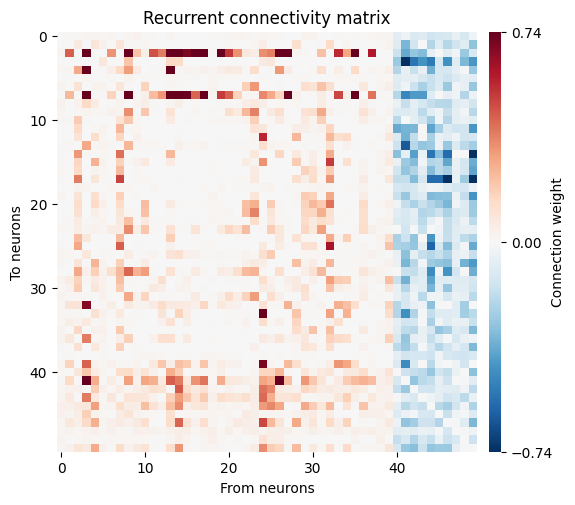

In [4]:
""" Visualize Matrices of RNN with Dale's Law """
W_rec = net.rnn.h2h.effective_weight().detach().numpy()
W_in = net.rnn.input2h.weight.detach().numpy()
W_out = net.fc.weight.detach().numpy()
print(W_rec.shape)
print(W_in.shape)
print(W_out.shape)

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
n_neuron = W_rec.shape[0]
# color scale
wlim = np.percentile(np.abs(W_rec), 99)
wlim = int(wlim * 100) / 100

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.7])
im = ax.imshow(
    W_rec,
    cmap='RdBu_r',
    vmin=-wlim,
    vmax=wlim,
    extent=(-0.5, n_neuron - 0.5,
            n_neuron - 0.5, -0.5),
    interpolation='nearest'
)
plt.xlabel('From neurons')
plt.ylabel('To neurons')
plt.title('Recurrent connectivity matrix')
for loc in ['left', 'right', 'top', 'bottom']:
    ax.spines[loc].set_visible(False)
cax = fig.add_axes([0.82, 0.1, 0.02, 0.7])
cb = plt.colorbar(
    im,
    cax=cax,
    ticks=[-wlim, 0, wlim]
)
cb.set_label('Connection weight', labelpad=-1)
cb.outline.set_linewidth(0)

plt.show()

In [5]:
""" Free the teacher RNN and do the sanity check to see if it can recover the result """
inputs, labels = dataset()
inputs = torch.from_numpy(inputs).float()

with torch.no_grad():       
    _, r1 = net(inputs)
    _, r2 = net(inputs)

mse = torch.mean((r1 - r2) ** 2)
print("MSE:", mse.item())

MSE: 0.0


In [6]:
""" Freeze the teacher RNN and generate data (inputs = trial time*1*3) """
# make sure to freeze the teacher rnn even there is no updating procedure
for p in net.parameters():
    p.requires_grad = False
# record teacher rnn for training
teacher_rs = [] # for student B and D
teacher_outputs = [] # for student C
teacher_labels = [] # for student A
teacher_inputs = []
# save information for analysis
trial_infos = {}
activity_dict = {}
stim_activity = [[], []]  # save response for ground-truth 0 and 1
# keep the input stimulus and fixation time constant
env.reset() 
env.timing.update({'fixation': ('constant', 500),
                   'stimulus': ('constant', 500)})

num_trial = 500 # use 500 new trials
for i in range(num_trial):
    env.new_trial()
    ob, gt = env.ob, env.gt # get input and ground truth (labels/gt)
    inputs = torch.from_numpy(ob[:, np.newaxis, :]).type(torch.float) # rnn requires input structure as (time,batch,input), so we add np.newaxis as batch=1
    with torch.no_grad(): # do not train RNN, only generate data
        output, activity = net(inputs) # output is the logits at every timestep, activity is r
    teacher_inputs.append(inputs.cpu().numpy()) # teacher input is before bias
    teacher_outputs.append(output.detach().cpu().numpy()) # decision logits calculated by r
    teacher_rs.append(activity.detach().cpu().numpy()) # r

    # Compute performance
    output = output.detach().numpy()
    choice = np.argmax(output[-1, 0, :])
    correct = choice == gt[-1]
    trial_info = env.trial.copy()
    trial_info.update({'correct': correct, 'choice': choice}) # add accuracy and choice to trial information
    trial_infos[i] = trial_info

    labels = torch.from_numpy(gt.flatten()).long()
    teacher_labels.append(labels.cpu().numpy()) # save labels

    activity = activity[:, 0, :].detach().numpy()
    activity_dict[i] = activity # save activity (no batch) for pca/plotting
    # Compute stimulus selectivity for all units
    # Compute each neuron's response in trials where ground_truth=0 and 1 respectively
    activity = activity[env.start_ind['stimulus']: env.end_ind['stimulus']]
    stim_activity[env.trial['ground_truth']].append(activity)

teacher_accuracy = np.mean([val['correct'] for val in trial_infos.values()])
print('Average performance', teacher_accuracy)

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.timing to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.timing` for environment variables or `env.get_wrapper_attr('timing')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.trial` for environment variables or `env.get_wrapper_attr('trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.start_ind to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.start_ind` for environment variabl

Average performance 0.856


Text(0, 0.5, 'Activity')

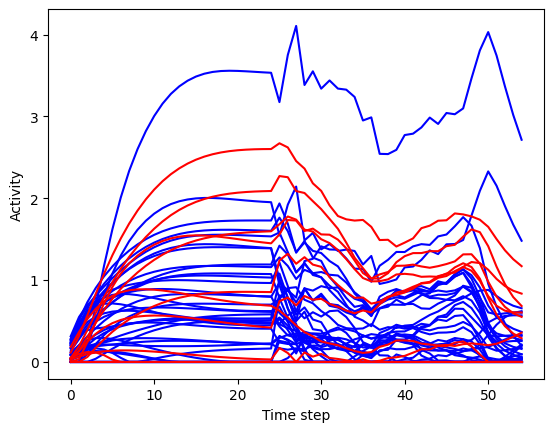

In [7]:
""" Plot teacher RNN neural activity from sample trials """
e_size = net.rnn.e_size
trial = 2

plt.figure()
_ = plt.plot(activity_dict[trial][:, :e_size], color='blue', label='Excitatory')
_ = plt.plot(activity_dict[trial][:, e_size:], color='red', label='Inhibitory')
plt.xlabel('Time step')
plt.ylabel('Activity')

In [8]:
# Student RNN and teacher RNN have the same structure
""" Train the student RNN by learning teacher's labels """
# Parameters updated during training (student_A)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_A = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_A = optim.Adam(student_A.parameters(), lr=0.001)
criterion_A = nn.CrossEntropyLoss()
running_loss_A = 0
print_step = 200
step = 0
for epoch in range(20): 
    indices = np.random.permutation(len(teacher_inputs)) # length of teacher_inputs = 500
    for idx in indices: # shuffled the inputs and select one each time to learn
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        labels = torch.from_numpy(teacher_labels[idx]).long()

        optimizer_A.zero_grad()
        output_A, activity_A = student_A(inputs)
        output_A = output_A.view(-1, output_size) # reshape into (trial_time, 3)
        loss_A = criterion_A(output_A, labels)
        loss_A.backward()
        optimizer_A.step()
        running_loss_A += loss_A.item()

        step += 1
        if step % print_step == 0:
            running_loss_A /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_A))
            running_loss_A = 0

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(


Step 200, Loss 0.3525


Step 400, Loss 0.1588


Step 600, Loss 0.1342


Step 800, Loss 0.1115


...

Step 9200, Loss 0.0573


Step 9400, Loss 0.0549


Step 9600, Loss 0.0567


Step 9800, Loss 0.0539


Step 10000, Loss 0.0576


In [9]:
""" Train the student RNN by learning the teacher's hidden activity r """
# Parameters updated during training (student_B)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_B = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_B = optim.Adam(student_B.parameters(), lr=0.001)
criterion_B = nn.MSELoss() # Mean squared error = loss
running_loss_B = 0
print_step = 200
step = 0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs)) # 500
    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_r = torch.from_numpy(teacher_rs[idx]).float()

        optimizer_B.zero_grad()
        output_B, activity_B = student_B(inputs)
        loss_B = criterion_B(activity_B, target_r)
        loss_B.backward()
        optimizer_B.step()

        running_loss_B += loss_B.item() 
        step += 1
        if step % print_step == 0:
            running_loss_B /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_B))
            running_loss_B = 0

Step 200, Loss 0.4089


Step 400, Loss 0.3207


Step 600, Loss 0.3092


Step 800, Loss 0.3065


Step 1000, Loss 0.3009


...

Step 9200, Loss 0.2764


Step 9400, Loss 0.2756


Step 9600, Loss 0.2762


Step 9800, Loss 0.2771


Step 10000, Loss 0.2768


In [10]:
# learn teacher's every logit, loss = 0.16
# learn every time step probability distribution, loss = 0.01
# learn the last step logit, loss = 0.03
# Train the student network by the final step probability distribution but using teacher's input->hidden & hidden-> output layer, loss = 3.20
""" Train student RNN by learning teacher's final-step behavior probability distribution """
# Parameters updated during training (student_C)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_C = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_C = optim.Adam(student_C.parameters(), lr=0.001)
criterion_C = nn.KLDivLoss(reduction='batchmean') # learn the probability distribution

running_loss_C = 0
print_step = 200
step = 0
temperature = 1.0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs))

    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_output = torch.from_numpy(teacher_outputs[idx]).float()
        optimizer_C.zero_grad()
        output_C, activity_C = student_C(inputs)
        # only learn the last step
        teacher_prob = torch.softmax(target_output[-1, 0, :] / temperature, dim=-1) # target has to be probability
        student_logprob = torch.log_softmax(output_C[-1, 0, :] / temperature, dim=-1) # input has to be log probability
        loss_C = criterion_C(student_logprob, teacher_prob)
        loss_C.backward()
        optimizer_C.step()

        running_loss_C += loss_C.item()
        step += 1
        if step % print_step == 0:
            running_loss_C /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_C))
            running_loss_C = 0

Step 200, Loss 0.1680


Step 400, Loss 0.1170


Step 600, Loss 0.0686


Step 800, Loss 0.0258


Step 1000, Loss 0.0205


...

Step 9200, Loss 0.0009


Step 9400, Loss 0.0008


Step 9600, Loss 0.0005


Step 9800, Loss 0.0007


Step 10000, Loss 0.0005


In [11]:
""" Train the student network by learning r but using teacher's input->hidden layer """
# Parameters updated during training (student_D)

# input -> hidden layer
# rnn.input2h.weight : not trainable (same as teacher)
# rnn.input2h.bias   : not trainable (same as teacher)

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)
def train_student_D(epochs=20, lr=0.001, name="D"):
    student = Net(input_size=input_size,
                  hidden_size=hidden_size,
                  output_size=output_size,
                  dt=env.dt,
                  sigma_rec=0)
    
    # Copy teacher (net) input -> hidden layer
    student.rnn.input2h.load_state_dict(net.rnn.input2h.state_dict())

    # Freeze everything first
    for p in student.parameters():
        p.requires_grad = False
    
    # Only train recurrent weight; optionally train recurrent bias (bias is NOT noise)
    student.rnn.h2h.weight.requires_grad = True
    if student.rnn.h2h.bias is not None: # since in EIRecLinear, bias = False (teacher bias equal to None), so the sentence is always not satisfied
        student.rnn.h2h.bias.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, student.parameters()), lr=lr)
    criterion = nn.MSELoss()

    running_loss = 0
    print_step = 200
    step = 0
    last_loss = None

    for epoch in range(epochs):
        indices = np.random.permutation(len(teacher_inputs))

        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()

            optimizer.zero_grad()
            output, activity = student(inputs)
            loss = criterion(activity, target_r)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            last_loss = loss.item()
            step += 1

            if step % print_step == 0:
                running_loss /= print_step
                print(f'Step {step}, Loss {running_loss:.4f}')
                running_loss = 0
    return student, last_loss

# student D has the same input->hidden layer as the teacher, and fit hidden layer weight only 
student_D, loss_D = train_student_D(epochs=20, lr=0.001, name="D activity-trained weight-only")

Step 200, Loss 0.2176


Step 400, Loss 0.0788


Step 600, Loss 0.0429


Step 800, Loss 0.0111


Step 1000, Loss 0.0083


...

Step 9200, Loss 0.0004


Step 9400, Loss 0.0002


Step 9600, Loss 0.0002


Step 9800, Loss 0.0002


Step 10000, Loss 0.0002


In [12]:
""" Evaluation """
def get_recurrent_weight(model):
    if hasattr(model.rnn.h2h, "effective_weight"): # if there is attribute effective_weight 
        return model.rnn.h2h.effective_weight().detach().numpy()
    return model.rnn.h2h.weight.detach().numpy()

def weight_corr(W_teacher, W_student):
    corr_signed = np.corrcoef(W_teacher.flatten(), W_student.flatten())[0, 1]
    corr_abs = np.corrcoef(np.abs(W_teacher).flatten(), np.abs(W_student).flatten())[0, 1]
    return corr_signed, corr_abs

def evaluate_activity_mse(student): # compare teacher r and student r
    criterion = nn.MSELoss()
    total_loss = 0
    n = 0
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()
            _, activity = student(inputs)
            loss = criterion(activity, target_r)
            total_loss += loss.item()
            n += 1
    return total_loss / n

def evaluate_accuracy(student):
    correct_list = []
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            labels = torch.from_numpy(teacher_labels[idx]).long()
            output, _ = student(inputs)
            # final-step choice
            choice = torch.argmax(output[-1, 0, :]).item()
            correct = choice == labels[-1].item()
            correct_list.append(correct)
    return np.mean(correct_list)

students_for_eval = [
    ("A label-trained", student_A),
    ("B activity-trained", student_B),
    ("C final-probability-trained", student_C),
    ("D activity-trained weight-only", student_D),
]
W_teacher = get_recurrent_weight(net)

eval_results = []
for name, student in students_for_eval:
    W_student = get_recurrent_weight(student)
    corr_signed, corr_abs = weight_corr(W_teacher, W_student)
    mean_mse = evaluate_activity_mse(student)
    mean_acc = evaluate_accuracy(student)
    eval_results.append({
        "name": name,
        "activity_mse": mean_mse,
        "accuracy": mean_acc,
        "signed_corr": corr_signed,
        "abs_corr": corr_abs,
        "diagonal_zero": np.allclose(np.diag(W_student), 0),
    })
for result in eval_results:
    print(result["name"])
    print("  activity MSE:", result["activity_mse"])
    print("  accuracy:", result["accuracy"])
    print("  signed W corr:", result["signed_corr"])
    print("  abs W corr:", result["abs_corr"])
    print("  diagonal zero:", result["diagonal_zero"])

A label-trained
  activity MSE: 19.93738510131836
  accuracy: 0.584
  signed W corr: 0.4244096678385528
  abs W corr: 0.1761372820006088
  diagonal zero: True
B activity-trained
  activity MSE: 0.2763378584682941
  accuracy: 0.112
  signed W corr: 0.37505584120549273
  abs W corr: 0.20009632184264867
  diagonal zero: True
C final-probability-trained
  activity MSE: 0.7235757540464401
  accuracy: 0.85
  signed W corr: 0.37317211741897277
  abs W corr: 0.13358369030117978
  diagonal zero: True
D activity-trained weight-only
  activity MSE: 0.000252387108921539
  accuracy: 0.55
  signed W corr: 0.7566848871771233
  abs W corr: 0.6749651214357444
  diagonal zero: True


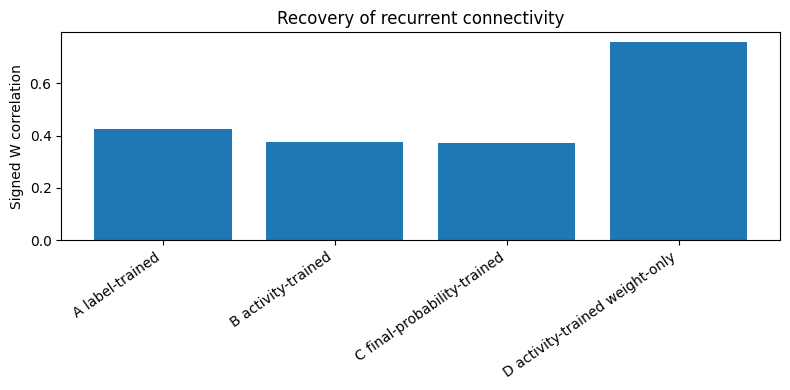

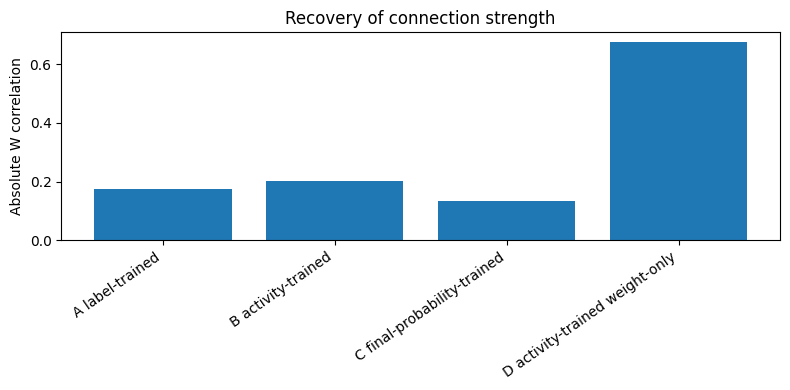

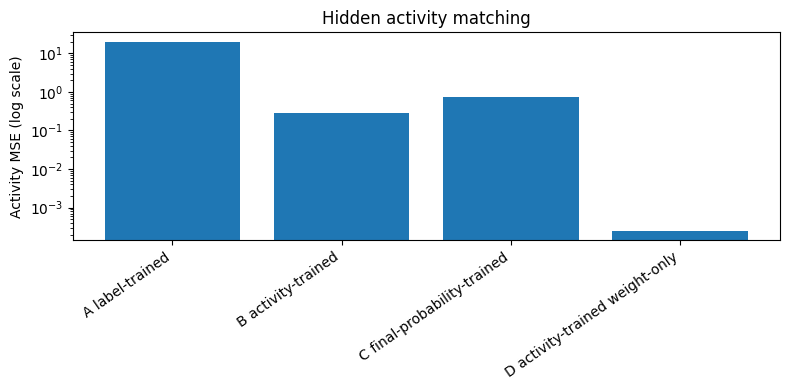

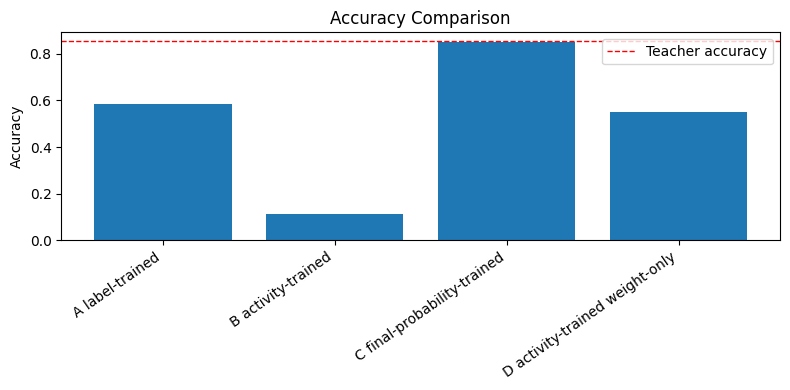

In [13]:
""" Summary plots """
names = [r["name"] for r in eval_results]
activity_mse = [r["activity_mse"] for r in eval_results]
signed_corr = [r["signed_corr"] for r in eval_results]
abs_corr = [r["abs_corr"] for r in eval_results]
accuracy = [r["accuracy"] for r in eval_results]

plt.figure(figsize=(8, 4))
plt.bar(names, signed_corr)
plt.ylabel("Signed W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of recurrent connectivity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, abs_corr)
plt.ylabel("Absolute W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of connection strength")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, activity_mse)
plt.yscale("log")
plt.ylabel("Activity MSE (log scale)")
plt.xticks(rotation=35, ha="right")
plt.title("Hidden activity matching")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, accuracy)
plt.axhline(teacher_accuracy, linestyle='--', linewidth=1, color='r', label='Teacher accuracy')
plt.ylabel("Accuracy")
plt.xticks(rotation=35, ha="right")
plt.title("Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()


Explained variance ratio:
PC1: 0.47201586
PC2: 0.28524384
PC3: 0.13637614
Total: 0.89363587


Teacher PC1-3 explain: 0.20563602


Teacher PC1-3 explain: 0.65690106


Teacher PC1-3 explain: 0.16343646


Teacher PC1-3 explain: 0.8896386


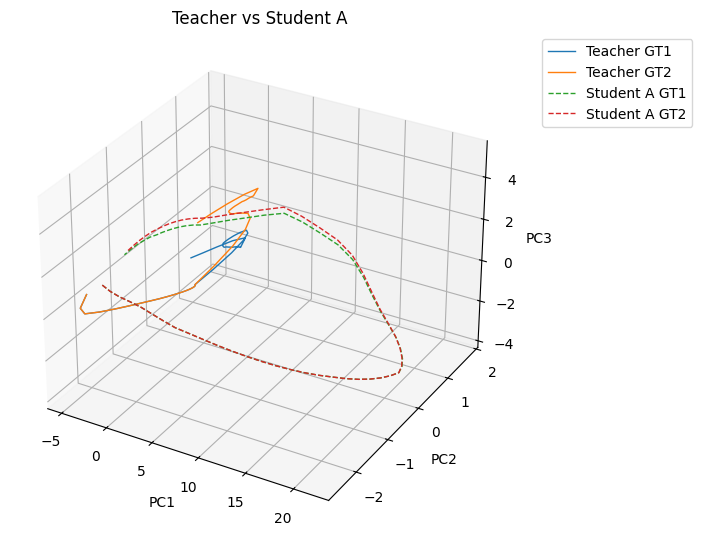

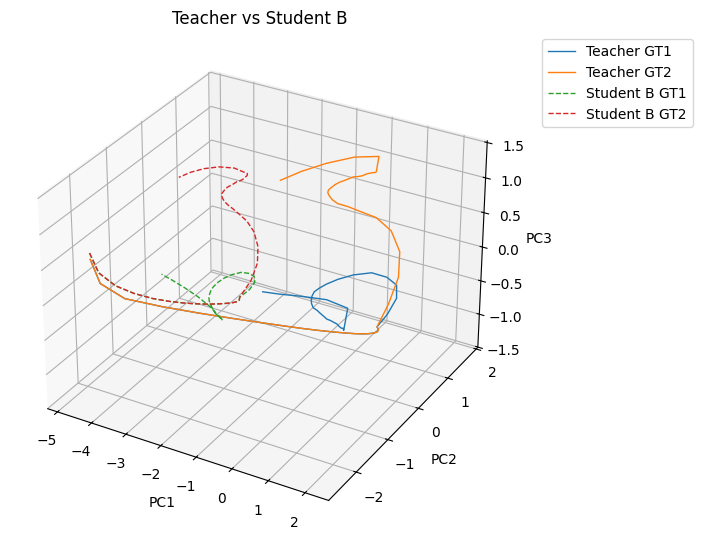

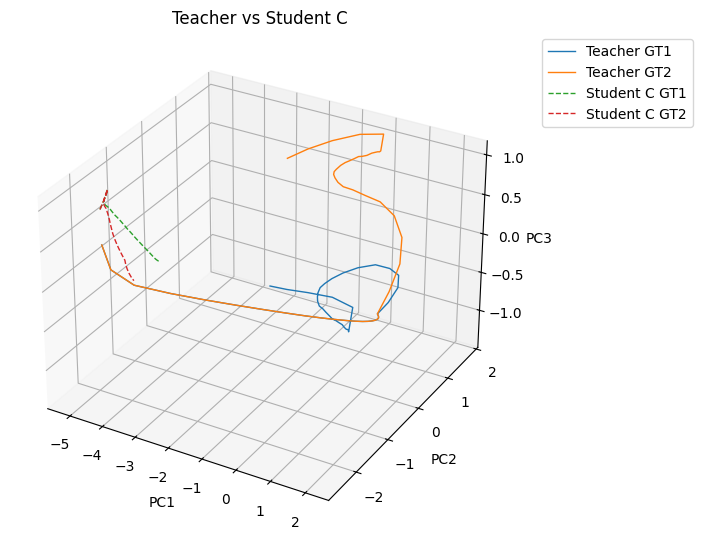

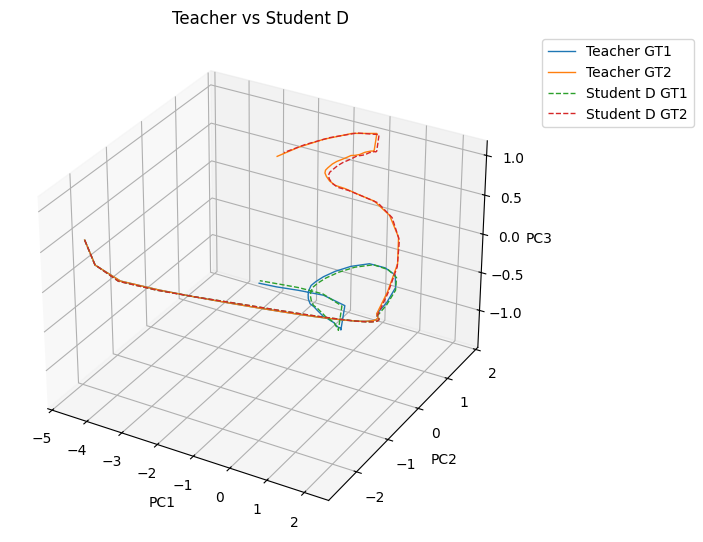

In [14]:
""" PCA comparison between teacher and students """
from sklearn.decomposition import PCA
# teacher activity
T = activity_dict[0].shape[0] # time of trial (55)
H = activity_dict[0].shape[1] # hidden size (50)
n_trial = len(activity_dict) # 500
teacher_activity = np.stack([activity_dict[i] for i in range(n_trial)], axis=0) # (n_trial, trial_time, hidden_size)
teacher_flat = teacher_activity.reshape(-1, H) # PCA require input with (sample=n_trial*trial_time, feature=neuron) 

# PCA on teacher
pca = PCA(n_components=3)
teacher_pca_flat = pca.fit_transform(teacher_flat) # -> (sample, 3), used to be 2
teacher_pca = teacher_pca_flat.reshape(n_trial, T, 3)
print("Explained variance ratio:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])
print("Total:", np.sum(pca.explained_variance_ratio_)) # explain about 90% of variance

# get student activity
def get_student_activity(student):
    student_activity = []
    with torch.no_grad():
        for idx in range(len(teacher_inputs)):
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            _, activity = student(inputs)
            activity = (activity[:, 0, :].detach().cpu().numpy())
            student_activity.append(activity)
    return np.stack(student_activity, axis=0)

# project student to teacher PCA space
def project_to_teacher_pca(student):
    student_activity = get_student_activity(student)
    student_flat = student_activity.reshape(-1, H)
    student_pca_flat = pca.transform(student_flat) # project onto 3 PCs of teacher
    student_pca = student_pca_flat.reshape(student_activity.shape[0], student_activity.shape[1], 3)
    # how much of student's variance can be explained by teacher's 3 PCs
    student_total_var = np.var(student_flat, axis=0).sum()
    student_pc_var = np.var(student_pca_flat, axis=0).sum()
    explained_ratio = (student_pc_var/student_total_var)
    print("Teacher PC1-3 explain:", explained_ratio)
    return student_pca, explained_ratio

student_A_pca, student_A_pca_overlap = project_to_teacher_pca(student_A)
student_B_pca, student_B_pca_overlap = project_to_teacher_pca(student_B)
student_C_pca, student_C_pca_overlap = project_to_teacher_pca(student_C)
student_D_pca, student_D_pca_overlap = project_to_teacher_pca(student_D)

# plot teacher vs one student
def plot_teacher_student_pca(student_pca, student_name): # average the outcome based on different ground truth
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    # separate by ground truth
    gt1_idx = []
    gt2_idx = []
    for i in range(n_trial):
        gt = teacher_labels[i][-1]
        if gt == 1:
            gt1_idx.append(i)
        else:
            gt2_idx.append(i)
    # mean trajectory
    teacher_mean_1 = np.mean(teacher_pca[gt1_idx], axis=0)
    teacher_mean_2 = np.mean(teacher_pca[gt2_idx], axis=0)

    student_mean_1 = np.mean(student_pca[gt1_idx], axis=0)
    student_mean_2 = np.mean(student_pca[gt2_idx], axis=0)

    ax.plot(teacher_mean_1[:,0], teacher_mean_1[:,1], teacher_mean_1[:,2], linewidth=1, label='Teacher GT1')
    ax.plot(teacher_mean_2[:,0], teacher_mean_2[:,1], teacher_mean_2[:,2], linewidth=1, label='Teacher GT2')
    ax.plot(student_mean_1[:,0], student_mean_1[:,1], student_mean_1[:,2], '--', linewidth=1, label=f'{student_name} GT1')
    ax.plot(student_mean_2[:,0], student_mean_2[:,1], student_mean_2[:,2], '--', linewidth=1, label=f'{student_name} GT2')

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'Teacher vs {student_name}')
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.subplots_adjust(right=0.75)
    plt.show()
    
plot_teacher_student_pca(student_A_pca, "Student A")
plot_teacher_student_pca(student_B_pca, "Student B")
plot_teacher_student_pca(student_C_pca, "Student C")
plot_teacher_student_pca(student_D_pca, "Student D") # best

In [15]:
""" Save results """
import json
results = {
    # teacher PCAs
    "pca_pc1": float(pca.explained_variance_ratio_[0]),
    "pca_pc2": float(pca.explained_variance_ratio_[1]),
    "pca_pc3": float(pca.explained_variance_ratio_[2]),
    "pca_total_3pc": float(np.sum(pca.explained_variance_ratio_[:3])),

    # student PCA overlap
    "A_pca_overlap": float(student_A_pca_overlap),
    "B_pca_overlap": float(student_B_pca_overlap),
    "C_pca_overlap": float(student_C_pca_overlap),
    "D_pca_overlap": float(student_D_pca_overlap),

    # accuracy
    "A_accuracy": float(eval_results[0]["accuracy"]),
    "B_accuracy": float(eval_results[1]["accuracy"]),
    "C_accuracy": float(eval_results[2]["accuracy"]),
    "D_accuracy": float(eval_results[3]["accuracy"]),

    # activity MSE
    "A_activity_mse": float(eval_results[0]["activity_mse"]),
    "B_activity_mse": float(eval_results[1]["activity_mse"]),
    "C_activity_mse": float(eval_results[2]["activity_mse"]),
    "D_activity_mse": float(eval_results[3]["activity_mse"]),

    # W correlation
    "A_signed_corr": float(eval_results[0]["signed_corr"]),
    "B_signed_corr": float(eval_results[1]["signed_corr"]),
    "C_signed_corr": float(eval_results[2]["signed_corr"]),
    "D_signed_corr": float(eval_results[3]["signed_corr"]),
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("results saved")

results saved
